In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
trades = pd.read_csv("historical_data (1).csv")
sentiment = pd.read_csv("fear_greed_index.csv")


In [123]:
trades.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [124]:
sentiment.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [125]:
print(trades.shape)

print(sentiment.shape)

(211224, 16)
(2644, 4)


In [126]:
print(trades.columns)

print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [127]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [128]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [129]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [130]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [131]:
print(
    "Trade duplicates:",
    trades.duplicated().sum()
)

print(
    "Sentiment duplicates:",
    sentiment.duplicated().sum()
)

Trade duplicates: 0
Sentiment duplicates: 0


In [132]:
trades.drop_duplicates(inplace=True)

sentiment.drop_duplicates(inplace=True)

In [133]:
print(trades.shape)

print(sentiment.shape)

(211224, 16)
(2644, 4)


In [134]:
trades['Timestamp IST'].head()

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [135]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    errors='coerce'
)

trades['date'] = trades['Timestamp IST'].dt.date

In [136]:
sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [137]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


In [138]:
trades[
    trades['Timestamp IST'].isnull()
].head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
224,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,DYDX,0.63005,28.7,18.08,BUY,NaT,350000.0,Open Long,0.0,0x7b46ccfbc6de6d29ed63041fc7608b01bc00943d76ed...,80499480660,True,0.006074,8.210000e+14,1.740000e+12,NaT
225,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,DYDX,0.63007,3072.9,1936.14,BUY,NaT,350028.7,Open Long,0.0,0x7b46ccfbc6de6d29ed63041fc7608b01bc00943d76ed...,80499480660,True,0.650543,6.870000e+13,1.740000e+12,NaT
226,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,DYDX,0.63007,2724.5,1716.63,BUY,NaT,353101.6,Open Long,0.0,0x7b46ccfbc6de6d29ed63041fc7608b01bc00943d76ed...,80499480660,True,0.576786,3.790000e+14,1.740000e+12,NaT
227,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,DYDX,0.63029,1568.6,988.67,BUY,NaT,355826.1,Open Long,0.0,0x7b46ccfbc6de6d29ed63041fc7608b01bc00943d76ed...,80499480660,True,0.332193,4.410000e+14,1.740000e+12,NaT
228,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,DYDX,0.63046,1473.6,929.05,BUY,NaT,357394.7,Open Long,0.0,0x7b46ccfbc6de6d29ed63041fc7608b01bc00943d76ed...,80499480660,True,0.312159,9.660000e+14,1.740000e+12,NaT


In [139]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [140]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed


In [141]:
merged.shape

(211224, 20)

In [142]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
)

sentiment['date'] = sentiment['date'].dt.date

In [143]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [144]:
merged.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed


In [145]:
print(merged.shape)

(211224, 20)


In [146]:
merged.groupby(
    'classification'
)['Closed PnL'].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64

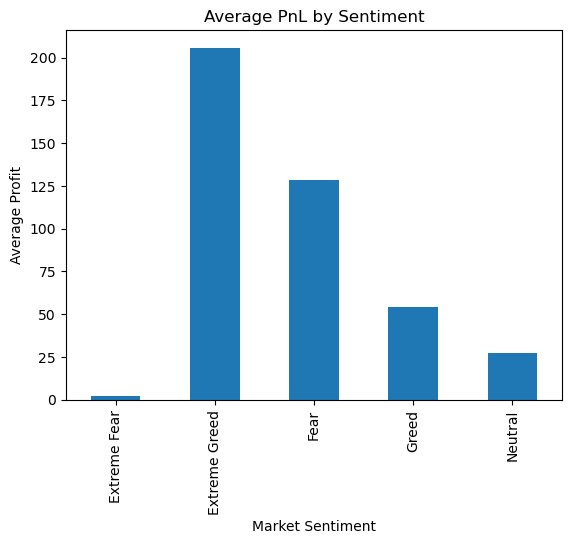

In [147]:
merged.groupby(
    'classification'
)['Closed PnL'].mean().plot(
    kind='bar'
)

plt.title(
    'Average PnL by Sentiment'
)

plt.xlabel(
    'Market Sentiment'
)

plt.ylabel(
    'Average Profit'
)

plt.show()

In [148]:
print("Rows, Columns:", merged.shape)

Rows, Columns: (211224, 20)


In [149]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     79225 non-null   datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

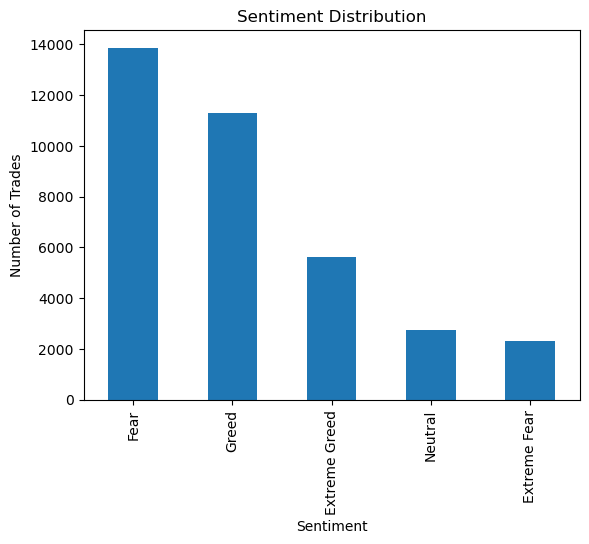

In [150]:
merged['classification'].value_counts().plot(
    kind='bar'
)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.show()

In [151]:
merged.groupby(
    'classification'
)['Closed PnL'].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64

In [152]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')


In [153]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum()

top_traders.sort_values(
    ascending=False
).head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

In [154]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')


In [155]:
merged.groupby(
    'Side'
)['Closed PnL'].mean()

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64

In [156]:
numeric_cols = merged.select_dtypes(
    include=['int64','float64']
)

numeric_cols.corr()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.125850,0.225265,0.001841,0.130714,0.009888,0.060718
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,-0.043753,0.006710,-0.003848,-0.040949,-0.063274,0.028075
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.045210,0.745939,0.000245,0.039755,0.016606,-0.017768
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,-0.082799,0.010559,0.001165,-0.105487,-0.058833,0.018263
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,-0.007250,0.084020,0.003466,-0.009745,0.014500,0.011000
Order ID,0.125850,-0.043753,0.045210,-0.082799,-0.007250,1.000000,0.039303,0.003880,0.929166,0.757307,-0.356088
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,0.039303,1.000000,0.000940,0.036888,-0.007287,0.005812
Trade ID,0.001841,-0.003848,0.000245,0.001165,0.003466,0.003880,0.000940,1.000000,0.002350,0.010721,-0.001029
Timestamp,0.130714,-0.040949,0.039755,-0.105487,-0.009745,0.929166,0.036888,0.002350,1.000000,0.749731,-0.314653
timestamp,0.009888,-0.063274,0.016606,-0.058833,0.014500,0.757307,-0.007287,0.010721,0.749731,1.000000,-0.428642


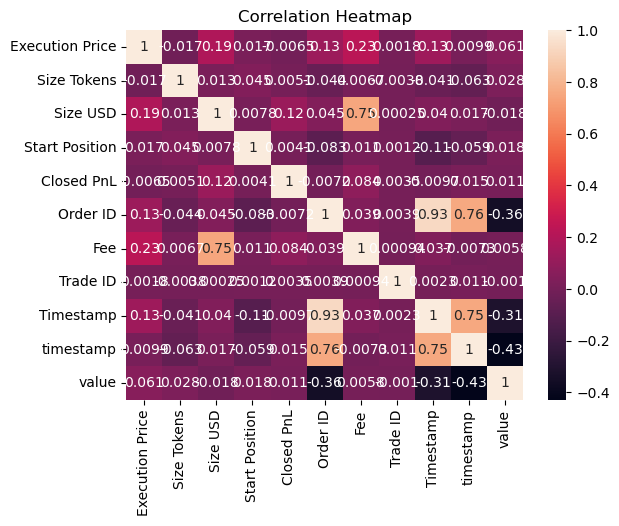

In [157]:
sns.heatmap(
    numeric_cols.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [158]:
merged['Closed PnL'].describe()

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

In [159]:
merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(
    ascending=False
)

classification
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Extreme Fear       1.891632
Name: Closed PnL, dtype: float64

In [160]:
merged['classification'].value_counts()

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

In [161]:
merged.groupby(
    'classification'
)['Closed PnL'].sum().sort_values(
    ascending=False
)

classification
Fear             1.779226e+06
Extreme Greed    1.156894e+06
Greed            6.096325e+05
Neutral          7.465674e+04
Extreme Fear     4.399937e+03
Name: Closed PnL, dtype: float64

'C:\\Users\\sangr\\assinment'